C:\Users\mahmo\AppData\Local\Temp\ipykernel_6540\2611258346.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=ratings, palette='viridis')


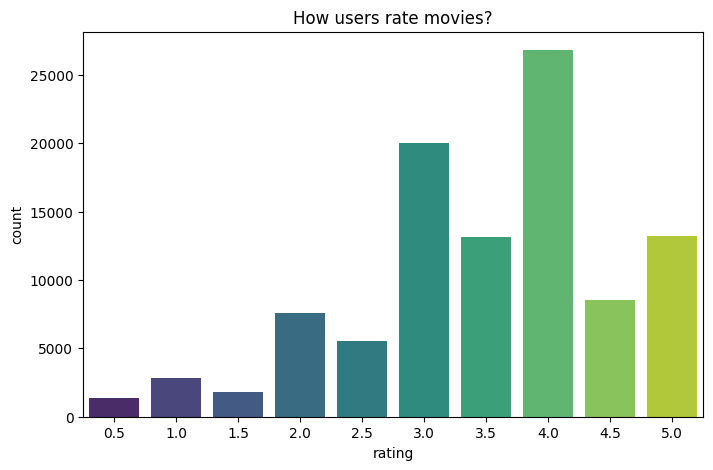

C:\Users\mahmo\AppData\Local\Temp\ipykernel_6540\2611258346.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_movies.values, y=names.values, palette='magma')


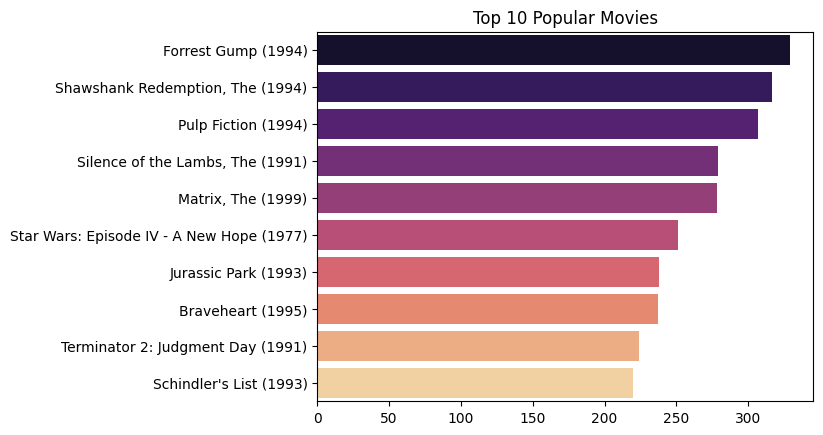

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

movies = pd.read_csv('../data/movies.csv')
ratings = pd.read_csv('../data/ratings.csv')

plt.figure(figsize=(8, 5))
sns.countplot(x='rating', data=ratings, palette='viridis')
plt.title('How users rate movies?')
plt.show()

top_movies = ratings.groupby('movieId').size().sort_values(ascending=False).head(10)
names = movies.set_index('movieId').loc[top_movies.index]['title']
sns.barplot(x=top_movies.values, y=names.values, palette='magma')
plt.title('Top 10 Popular Movies')
plt.show()

C:\Users\mahmo\AppData\Local\Temp\ipykernel_6540\4237888316.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=ratings, palette='viridis')


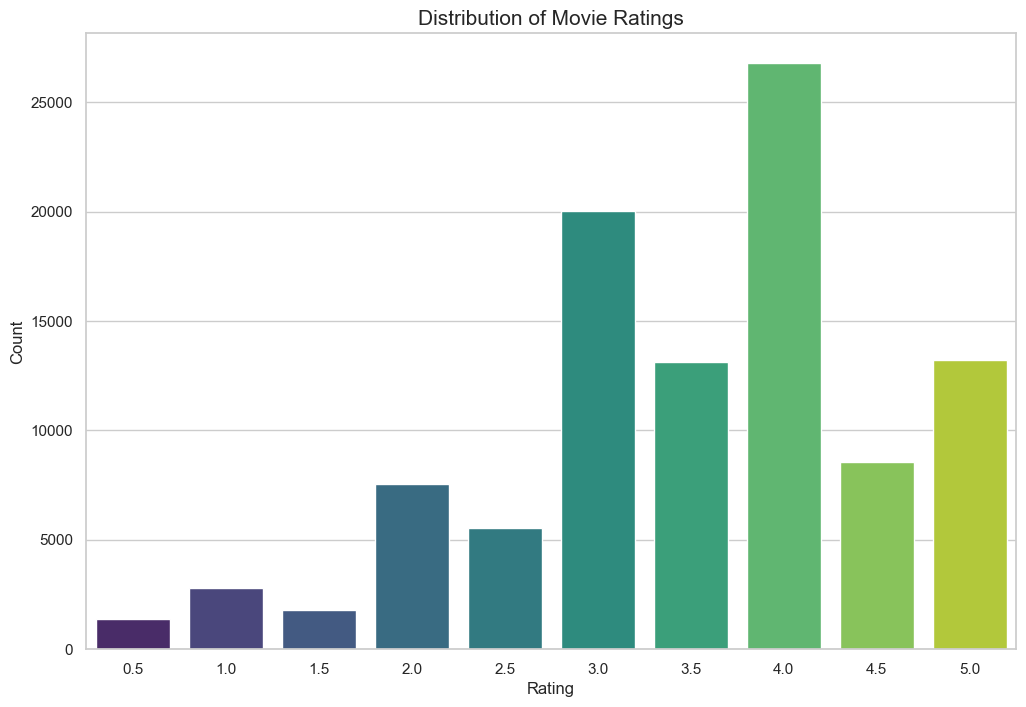

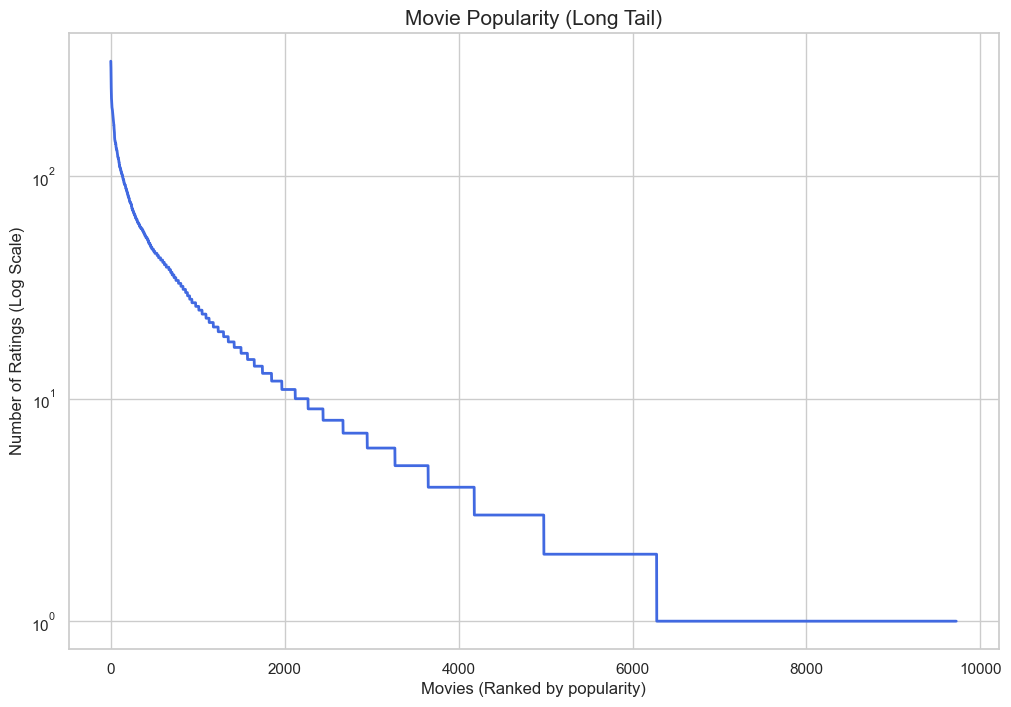

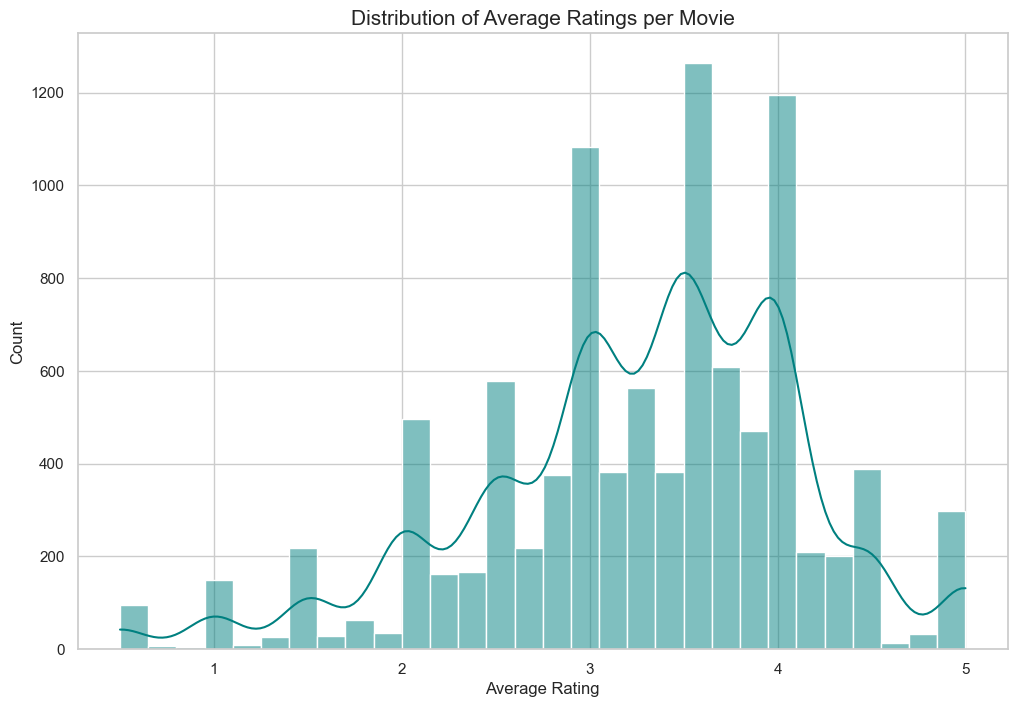

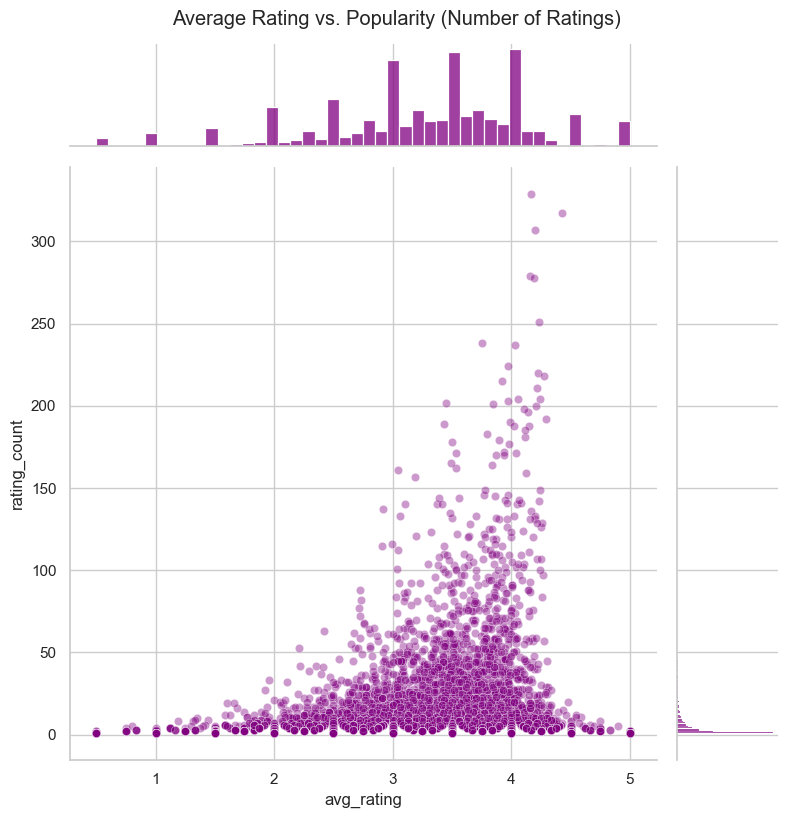

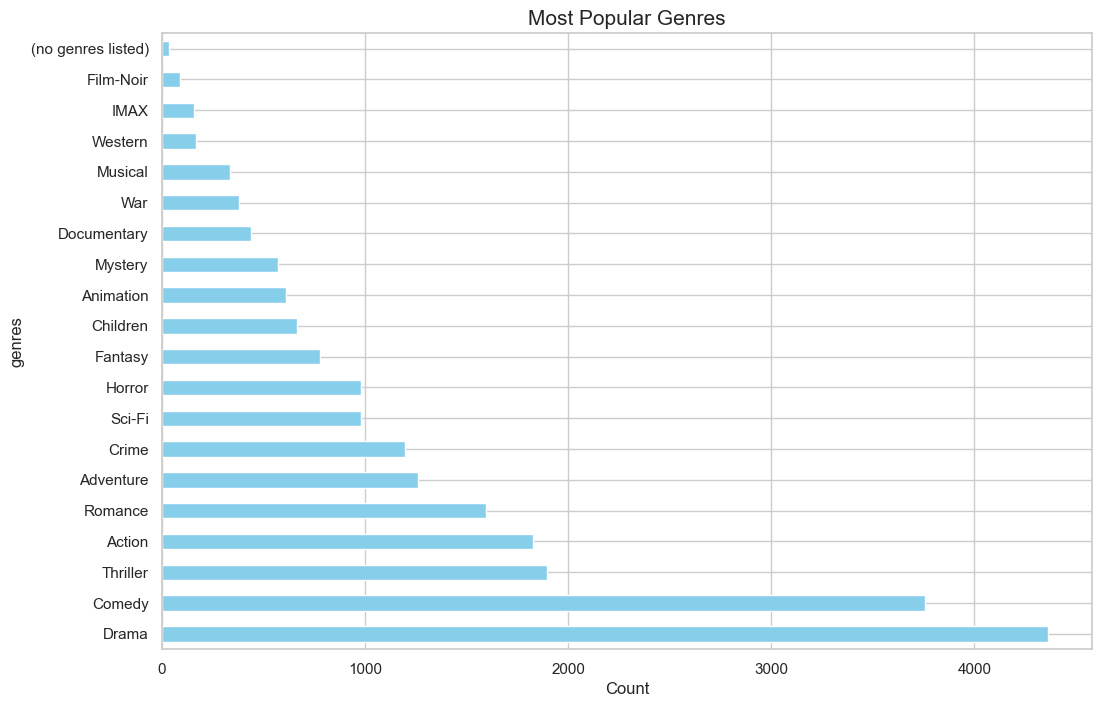

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

def run_full_eda(movies_path, ratings_path):
   
    plt.figure()
    sns.countplot(x='rating', data=ratings, palette='viridis')
    plt.title('Distribution of Movie Ratings', fontsize=15)
    plt.xlabel('Rating', fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.show()

    movie_counts = ratings.groupby('movieId').size().sort_values(ascending=False)
    plt.figure()
    plt.plot(movie_counts.values, color='royalblue', linewidth=2)
    plt.title('Movie Popularity (Long Tail)', fontsize=15)
    plt.xlabel('Movies (Ranked by popularity)', fontsize=12)
    plt.ylabel('Number of Ratings (Log Scale)', fontsize=12)
    plt.yscale('log') 
    plt.show()

    avg_ratings = ratings.groupby('movieId')['rating'].mean()
    plt.figure()
    sns.histplot(avg_ratings, bins=30, kde=True, color='teal')
    plt.title('Distribution of Average Ratings per Movie', fontsize=15)
    plt.xlabel('Average Rating', fontsize=12)
    plt.show()

    movie_stats = ratings.groupby('movieId').agg({'rating': ['mean', 'count']})
    movie_stats.columns = ['avg_rating', 'rating_count']
    sns.jointplot(x='avg_rating', y='rating_count', data=movie_stats, alpha=0.4, color='purple', height=8)
    plt.suptitle('Average Rating vs. Popularity (Number of Ratings)', y=1.02)
    plt.show()

    genres_split = movies['genres'].str.split('|').explode()
    plt.figure()
    genres_split.value_counts().plot(kind='barh', color='skyblue')
    plt.title('Most Popular Genres', fontsize=15)
    plt.xlabel('Count', fontsize=12)
    plt.show()

run_full_eda('data/movies.csv', 'data/ratings (2).csv')